<a href="https://colab.research.google.com/github/kunjpxtel/Market-Basket-Analysis/blob/main/Market_Basket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from pandas.plotting import parallel_coordinates

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv('/Groceries_dataset.csv')

In [7]:
print(df)

       Member_number        Date        itemDescription
0               1808  21-07-2015         tropical fruit
1               2552  05-01-2015             whole milk
2               2300  19-09-2015              pip fruit
3               1187  12-12-2015       other vegetables
4               3037  01-02-2015             whole milk
...              ...         ...                    ...
38760           4471  08-10-2014          sliced cheese
38761           2022  23-02-2014                  candy
38762           1097  16-04-2014               cake bar
38763           1510  03-12-2014  fruit/vegetable juice
38764           1521  26-12-2014               cat food

[38765 rows x 3 columns]


In [11]:
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [13]:
df.tail()

,Member_number,Date,itemDescription
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice
38764,1521,26-12-2014,cat food


In [14]:
df.shape

(38765, 3)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [17]:
df.isnull().sum().sort_values(ascending= False)

,0
Member_number,0
Date,0
itemDescription,0


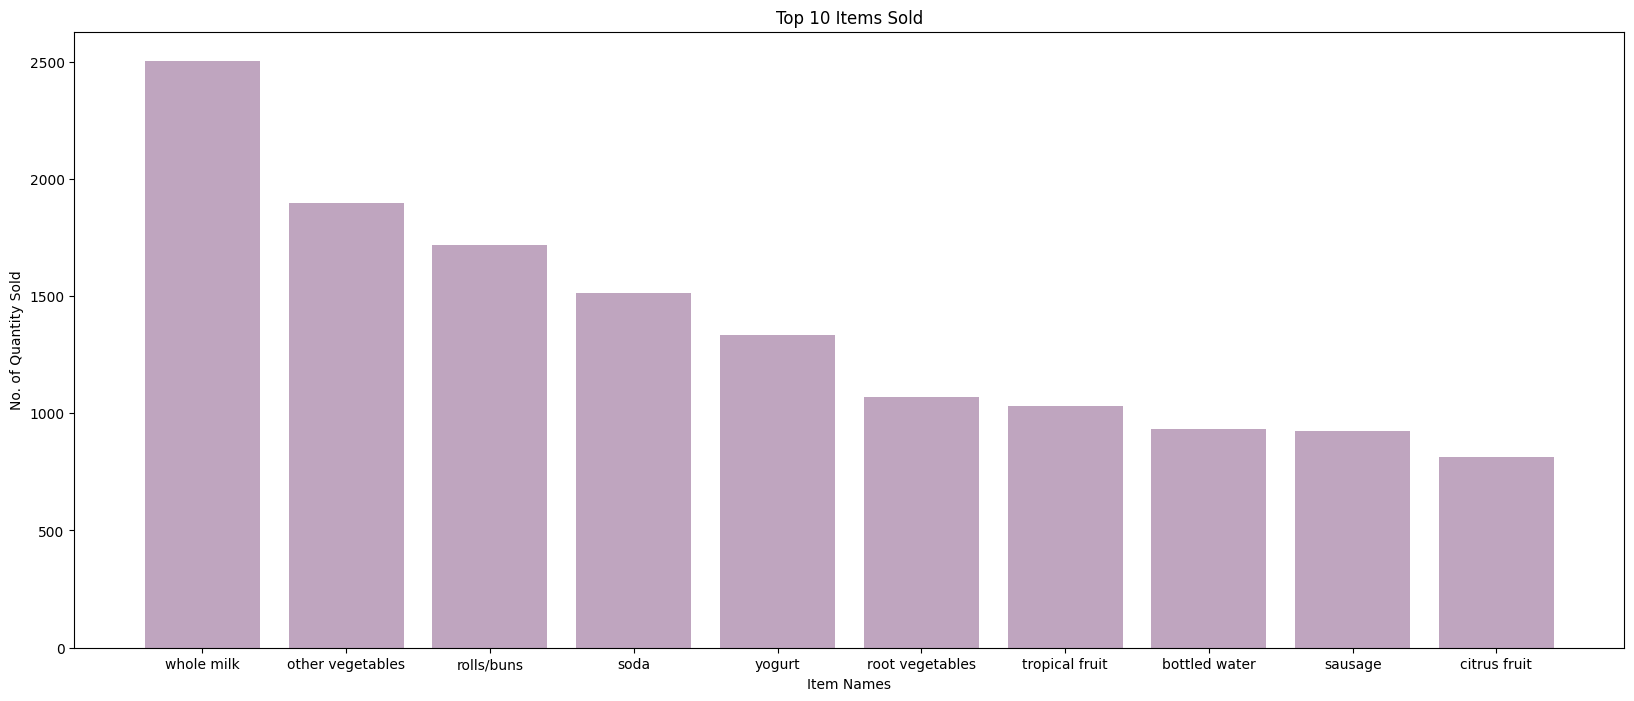

In [18]:
Item_distr = df.groupby(by = 'itemDescription').size().reset_index(name = 'frequency').sort_values(by = 'frequency', ascending = False).head(10)
bars = Item_distr["itemDescription"]
height = Item_distr["frequency"]
x_pos = np.arange(len(bars))
plt.figure(figsize=(20,8))
plt.bar(x_pos, height, color=(0.5,0.3,0.5,0.5))

plt.title("Top 10 Items Sold")
plt.xlabel("Item Names")
plt.ylabel("No. of Quantity Sold")


plt.xticks(x_pos, bars)
plt.show()

In [19]:
df_date = df.set_index(['Date'])
df_date

,Member_number,itemDescription
Date,,
21-07-2015,1808,tropical fruit
05-01-2015,2552,whole milk
19-09-2015,2300,pip fruit
12-12-2015,1187,other vegetables
01-02-2015,3037,whole milk
...,...,...
08-10-2014,4471,sliced cheese
23-02-2014,2022,candy
16-04-2014,1097,cake bar


[Text(0.5, 0, 'Date'), Text(0, 0.5, 'No. of Items Sold')]

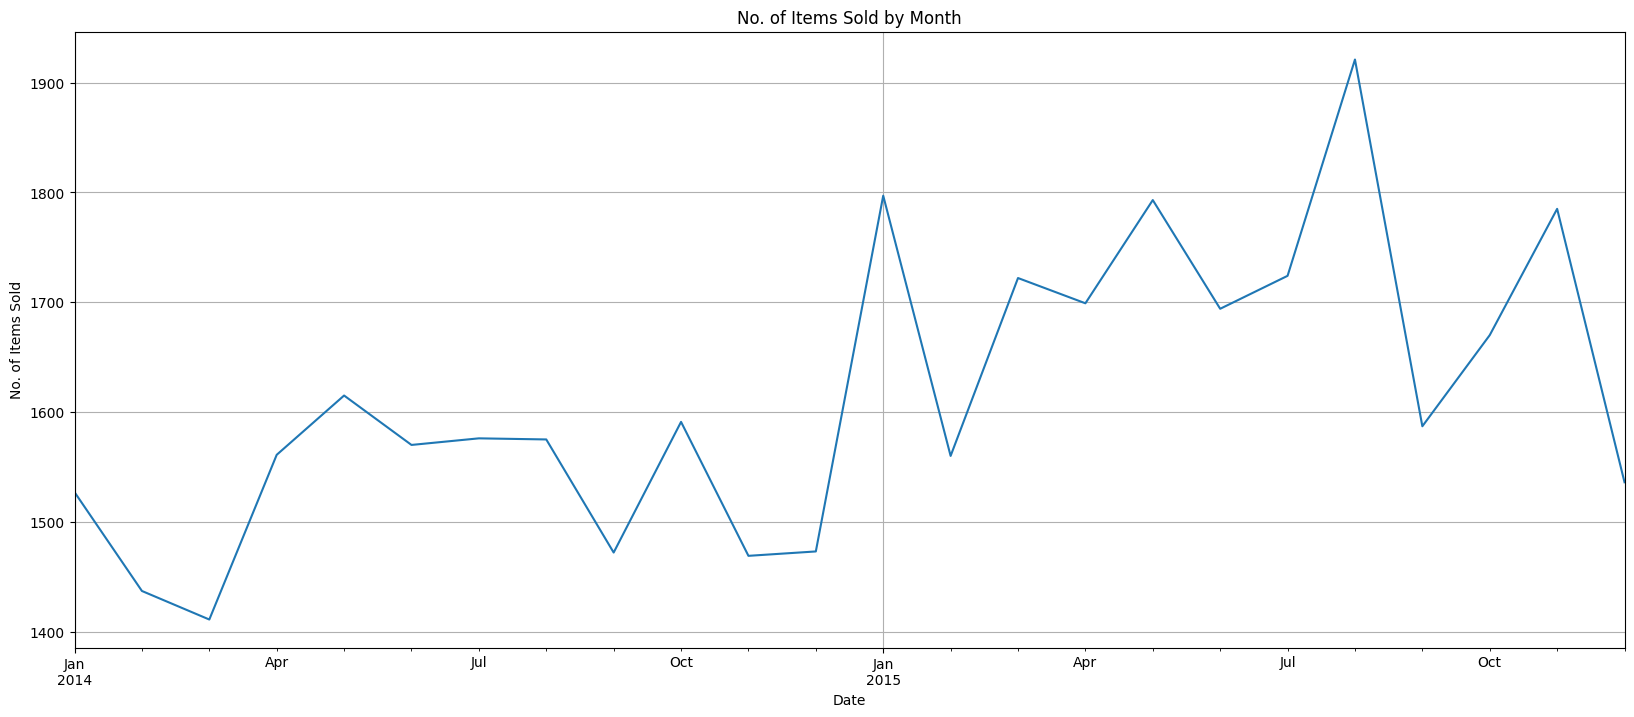

In [20]:
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df_date = df.set_index('Date')

ax = df_date.resample('ME')["itemDescription"].count().plot(
    figsize=(20, 8),
    grid=True,
    title="No. of Items Sold by Month"
)

ax.set(xlabel="Date", ylabel="No. of Items Sold")


In [21]:
cust_level = df[["Member_number", "itemDescription"]].sort_values(by = "Member_number", ascending=False)
cust_level["itemDescription"] = cust_level["itemDescription"].str.strip()
cust_level

,Member_number,itemDescription
34885,5000,semi-finished bread
25489,5000,other vegetables
3578,5000,soda
27877,5000,onions
9340,5000,bottled beer
...,...,...
24544,1000,yogurt
4843,1000,sausage
20992,1000,semi-finished bread
8395,1000,whole milk


In [22]:
transactions = [a[1]["itemDescription"].tolist() for a in list(cust_level.groupby(["Member_number"]))]

In [23]:
%pip install apyori


  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=0ab3ce8902922dcdddc82562d056d00158a7ae38f2adab4ce5495c11d5924136
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [24]:
%pip install mlxtend

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, max_len=2)

rules_df = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

rules_df = rules_df[rules_df['confidence'] >= 0.05]
rules_df[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
6918,(jam),(rice),0.001026,0.117647,9.358944
6919,(rice),(jam),0.001026,0.081633,9.358944
2783,(rum),(canned vegetables),0.001026,0.125000,6.090625
7882,(ready soups),(oil),0.001283,0.333333,5.987711
3068,(ready soups),(chewing gum),0.001026,0.266667,5.973946
2917,(tea),(cat food),0.001796,0.259259,5.909898
59,(soups),(Instant food products),0.001026,0.083333,5.413889
58,(Instant food products),(soups),0.001026,0.066667,5.413889
4498,(decalcifier),(dessert),0.001026,0.444444,5.140785
2707,(canned fruit),(soft cheese),0.001026,0.190476,5.050858


In [25]:
results = list(rules_df)

In [26]:
results

['antecedents',
 'consequents',
 'antecedent support',
 'consequent support',
 'support',
 'confidence',
 'lift',
 'representativity',
 'leverage',
 'conviction',
 'zhangs_metric',
 'jaccard',
 'certainty',
 'kulczynski']

In [29]:
import pandas as pd
from apyori import apriori

#Transactions are grouped properly
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()

#Freshly run Apriori
fresh_rules = apriori(transactions, min_support=0.001, min_confidence=0.05, min_lift=1.0)

#Run exact index parsing logic
lhs = [', '.join(list(result[2][0][0])) for result in fresh_rules]
fresh_rules = apriori(transactions, min_support=0.001, min_confidence=0.05, min_lift=1.0) # Reset generator
rhs = [', '.join(list(result[2][0][1])) for result in fresh_rules]
fresh_rules = apriori(transactions, min_support=0.001, min_confidence=0.05, min_lift=1.0) # Reset generator

supports = [result[1] for result in fresh_rules]
fresh_rules = apriori(transactions, min_support=0.001, min_confidence=0.05, min_lift=1.0)
confidences = [result[2][0][2] for result in fresh_rules]
fresh_rules = apriori(transactions, min_support=0.001, min_confidence=0.05, min_lift=1.0)
lifts = [result[2][0][3] for result in fresh_rules]

#Build the DataFrame
resultsindataframe = pd.DataFrame(
    list(zip(lhs, rhs, supports, confidences, lifts)),
    columns=['Left Hand Side', 'Right Hand Side', 'Support', 'Confidences', 'Lifts']
)

#Convert types to numeric
resultsindataframe['Support'] = pd.to_numeric(resultsindataframe['Support'])
resultsindataframe['Confidences'] = pd.to_numeric(resultsindataframe['Confidences'])
resultsindataframe['Lifts'] = pd.to_numeric(resultsindataframe['Lifts'])

#Display the data
resultsindataframe.nlargest(n=15, columns='Lifts')


,Left Hand Side,Right Hand Side,Support,Confidences,Lifts
88,"whole milk, sausage",yogurt,0.001470,0.164179,1.911760
34,specialty chocolate,citrus fruit,0.001403,0.087866,1.653762
43,flour,tropical fruit,0.001069,0.109589,1.617141
16,beverages,sausage,0.001537,0.092742,1.536764
63,napkins,pastry,0.001738,0.078550,1.518529
70,processed cheese,root vegetables,0.001069,0.105263,1.513019
54,hard cheese,pip fruit,0.001069,0.072727,1.482586
81,soft cheese,yogurt,0.001270,0.126667,1.474952
37,curd,sausage,0.002941,0.087302,1.446615
42,detergent,yogurt,0.001069,0.124031,1.444261


In [32]:
top_15_confidence = resultsindataframe.nlargest(n=15, columns='Confidences')

In [33]:
top_15_confidence

,Left Hand Side,Right Hand Side,Support,Confidences,Lifts
85,"rolls/buns, sausage",whole milk,0.001136,0.212500,1.345594
87,"soda, sausage",whole milk,0.001069,0.179775,1.138374
80,semi-finished bread,whole milk,0.001671,0.176056,1.114825
88,"whole milk, sausage",yogurt,0.001470,0.164179,1.911760
41,detergent,whole milk,0.001403,0.162791,1.030824
53,ham,whole milk,0.002740,0.160156,1.014142
9,,whole milk,0.157923,0.157923,1.000000
69,processed cheese,rolls/buns,0.001470,0.144737,1.315734
67,packaged fruit/vegetables,rolls/buns,0.001203,0.141732,1.288421
72,seasonal products,rolls/buns,0.001002,0.141509,1.286395


In [35]:
sorted_df = resultsindataframe.sort_values(by='Confidences', ascending=False)

In [36]:
sorted_df

,Left Hand Side,Right Hand Side,Support,Confidences,Lifts
85,"rolls/buns, sausage",whole milk,0.001136,0.212500,1.345594
87,"soda, sausage",whole milk,0.001069,0.179775,1.138374
80,semi-finished bread,whole milk,0.001671,0.176056,1.114825
88,"whole milk, sausage",yogurt,0.001470,0.164179,1.911760
41,detergent,whole milk,0.001403,0.162791,1.030824
...,...,...,...,...,...
14,berries,pip fruit,0.001136,0.052147,1.063051
3,,pastry,0.051728,0.051728,1.000000
39,dessert,shopping bags,0.001203,0.050992,1.071609
36,cream cheese,shopping bags,0.001203,0.050847,1.068582


In [39]:
sorted1_df = resultsindataframe.sort_values(by='Support', ascending=False)

In [40]:
sorted1_df

,Left Hand Side,Right Hand Side,Support,Confidences,Lifts
9,,whole milk,0.157923,0.157923,1.000000
2,,other vegetables,0.122101,0.122101,1.000000
4,,rolls/buns,0.110005,0.110005,1.000000
7,,soda,0.097106,0.097106,1.000000
10,,yogurt,0.085879,0.085879,1.000000
...,...,...,...,...,...
40,detergent,rolls/buns,0.001002,0.116279,1.057037
26,salty snack,canned beer,0.001002,0.053381,1.137802
72,seasonal products,rolls/buns,0.001002,0.141509,1.286395
58,hygiene articles,root vegetables,0.001002,0.073171,1.051733


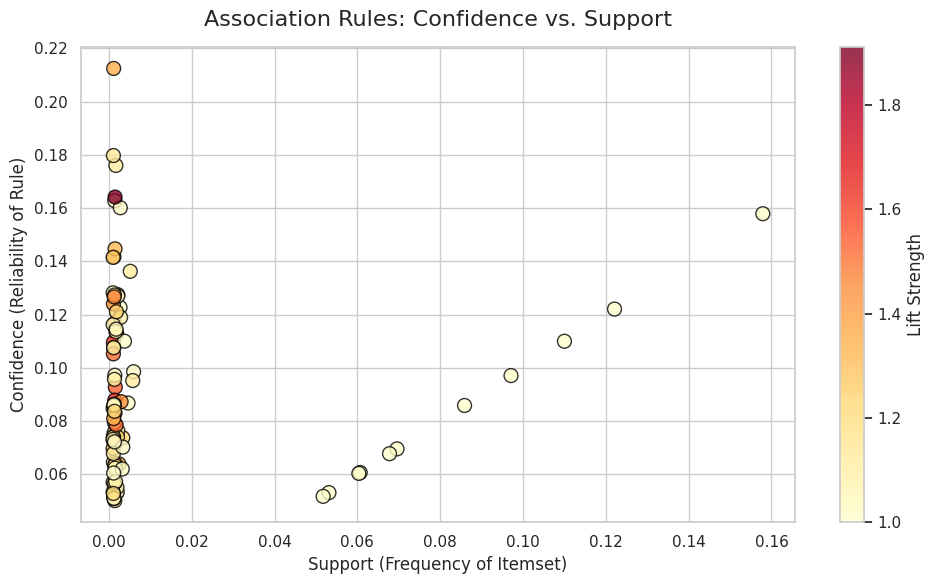

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

#Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

#Create scatter plot
scatter = plt.scatter(
    x=resultsindataframe['Support'],
    y=resultsindataframe['Confidences'],
    c=resultsindataframe['Lifts'],
    cmap='YlOrRd',  # Yellow to Orange to Red gradient
    alpha=0.8,
    edgecolors='black',
    s=100  # Size of points
)

#Add legend
cbar = plt.colorbar(scatter)
cbar.set_label('Lift Strength', fontsize=12)

#Titles and labels
plt.title('Association Rules: Confidence vs. Support', fontsize=16, pad=15)
plt.xlabel('Support (Frequency of Itemset)', fontsize=12)
plt.ylabel('Confidence (Reliability of Rule)', fontsize=12)

plt.tight_layout()
plt.show()


This scatter plot, titled '**Association Rules: Confidence vs. Support**', visually represents the relationship between three key metrics for association rules: **Support**, **Confidence**, and **Lift**. Each point on the plot corresponds to an individual association rule found in your dataset.

***The x-axis (Support)*** indicates how frequently the itemset (the items involved in the rule) appears in the dataset. Higher support values mean the items are purchased together more often.

***The y-axis (Confidence)*** measures the reliability of the association rule. It tells you how likely it is that the 'Right Hand Side' items are purchased given that the 'Left Hand Side' items have been purchased. Higher confidence means a stronger predictive power of the rule.

***The color of each point (Lift Strength)*** represents the 'Lift' metric, with a color gradient from yellow to orange to red. Lift indicates how much more likely the 'Right Hand Side' items are purchased when the 'Left Hand Side' items are present, compared to their individual probabilities. A lift value greater than 1 suggests a positive correlation between the items, meaning they are more likely to be bought together. The warmer the color (closer to red), the higher the lift, indicating a stronger positive association that is not due to chance alone.

In [47]:
import plotly.graph_objects as go

#Filter to top 15 rules by confidence
top_rules = resultsindataframe.nlargest(15, 'Confidences')

#Create Parallel Categories Diagram
fig = go.Figure(data=
    go.Parcats(
        dimensions=[
            {'label': 'Left Hand Side (If they buy...)', 'values': top_rules['Left Hand Side']},
            {'label': 'Right Hand Side (...they also buy)', 'values': top_rules['Right Hand Side']}
        ],
        line={'color': top_rules['Confidences'], 'colorscale': 'Viridis'},
        hoveron='category',
        hoverinfo='count+probability'
    )
)

fig.update_layout(
    title_text="Top 15 Rules: Parallel Item Coordinates Pathway",
    font=dict(size=12)
)

fig.show()


This chart, titled '**Top 15 Rules: Parallel Item Coordinates Pathway**', is an interactive Parallel Categories Diagram. It visualizes the flow of the top 15 association rules based on their confidence.

***The Left Hand Side (If they buy...)*** axis on the left lists the antecedent item(s) of the rules. These are the items a customer buys first.

***The Right Hand Side (...they also buy)*** axis on the right lists the consequent item(s) of the rules. These are the items a customer is likely to buy next, given the antecedent.

***Each line*** connecting a value on the 'Left Hand Side' to a value on the 'Right Hand Side' represents an individual association rule. The thickness of the line can implicitly indicate the frequency of that specific rule.

***The color of each line*** is determined by the 'Confidences' metric of the rule, using a 'Viridis' color scale. This means that rules with higher confidence will appear in a different shade than those with lower confidence, allowing for a visual assessment of rule strength.

***The chart is interactive:*** hovering over a category (an item on either axis) will display additional information, such as the count of rules passing through that category and its associated probability. This helps in understanding the distribution and impact of different items within the most confident rules.

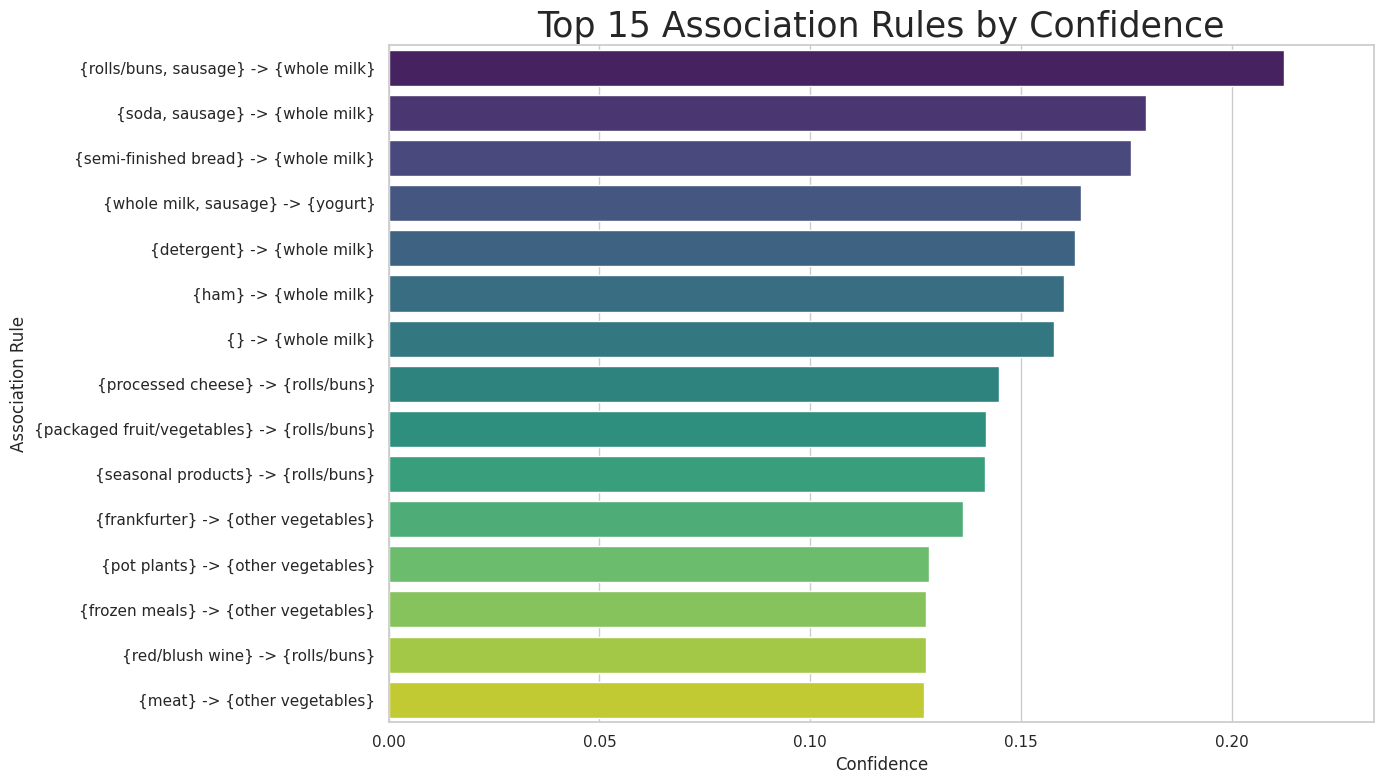

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine 'Left Hand Side' and 'Right Hand Side' for better labels
top_15_confidence['Rule'] = top_15_confidence.apply(lambda x: f"{{{x['Left Hand Side']}}} -> {{{x['Right Hand Side']}}}", axis=1)

# Sort by confidence to ensure the chart is ordered
top_15_confidence_sorted = top_15_confidence.sort_values(by='Confidences', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='Confidences', y='Rule', hue='Rule', data=top_15_confidence_sorted, palette='viridis', legend=False)
plt.title('Top 15 Association Rules by Confidence', fontsize=25)
plt.xlabel('Confidence', fontsize=12)
plt.ylabel('Association Rule', fontsize=12)
plt.xlim(0, top_15_confidence_sorted['Confidences'].max() * 1.1) # Add some padding to x-axis
plt.tight_layout()
plt.show()

This bar chart, titled '**Top 15 Association Rules by Confidence**', visually represents the strongest association rules based on their 'Confidences' metric.

***The x-axis (Confidence)*** shows the confidence value for each rule. Confidence indicates the probability that the 'Right Hand Side' items will be purchased given that the 'Left Hand Side' items have been purchased. A higher confidence value means the rule is more reliable.

***The y-axis (Association Rule)*** lists the top 15 association rules. Each rule is formatted to show the 'Left Hand Side' items (antecedents) and the 'Right Hand Side' items (consequents), for example, {rolls/buns, sausage} -> {whole milk}.

***The color of each bar*** is determined by the viridis palette, which helps distinguish between different rules but does not inherently represent a specific metric beyond visual separation. The length of each bar directly corresponds to the confidence of that particular association rule, making it easy to see which rules have the highest confidence (longest bars).


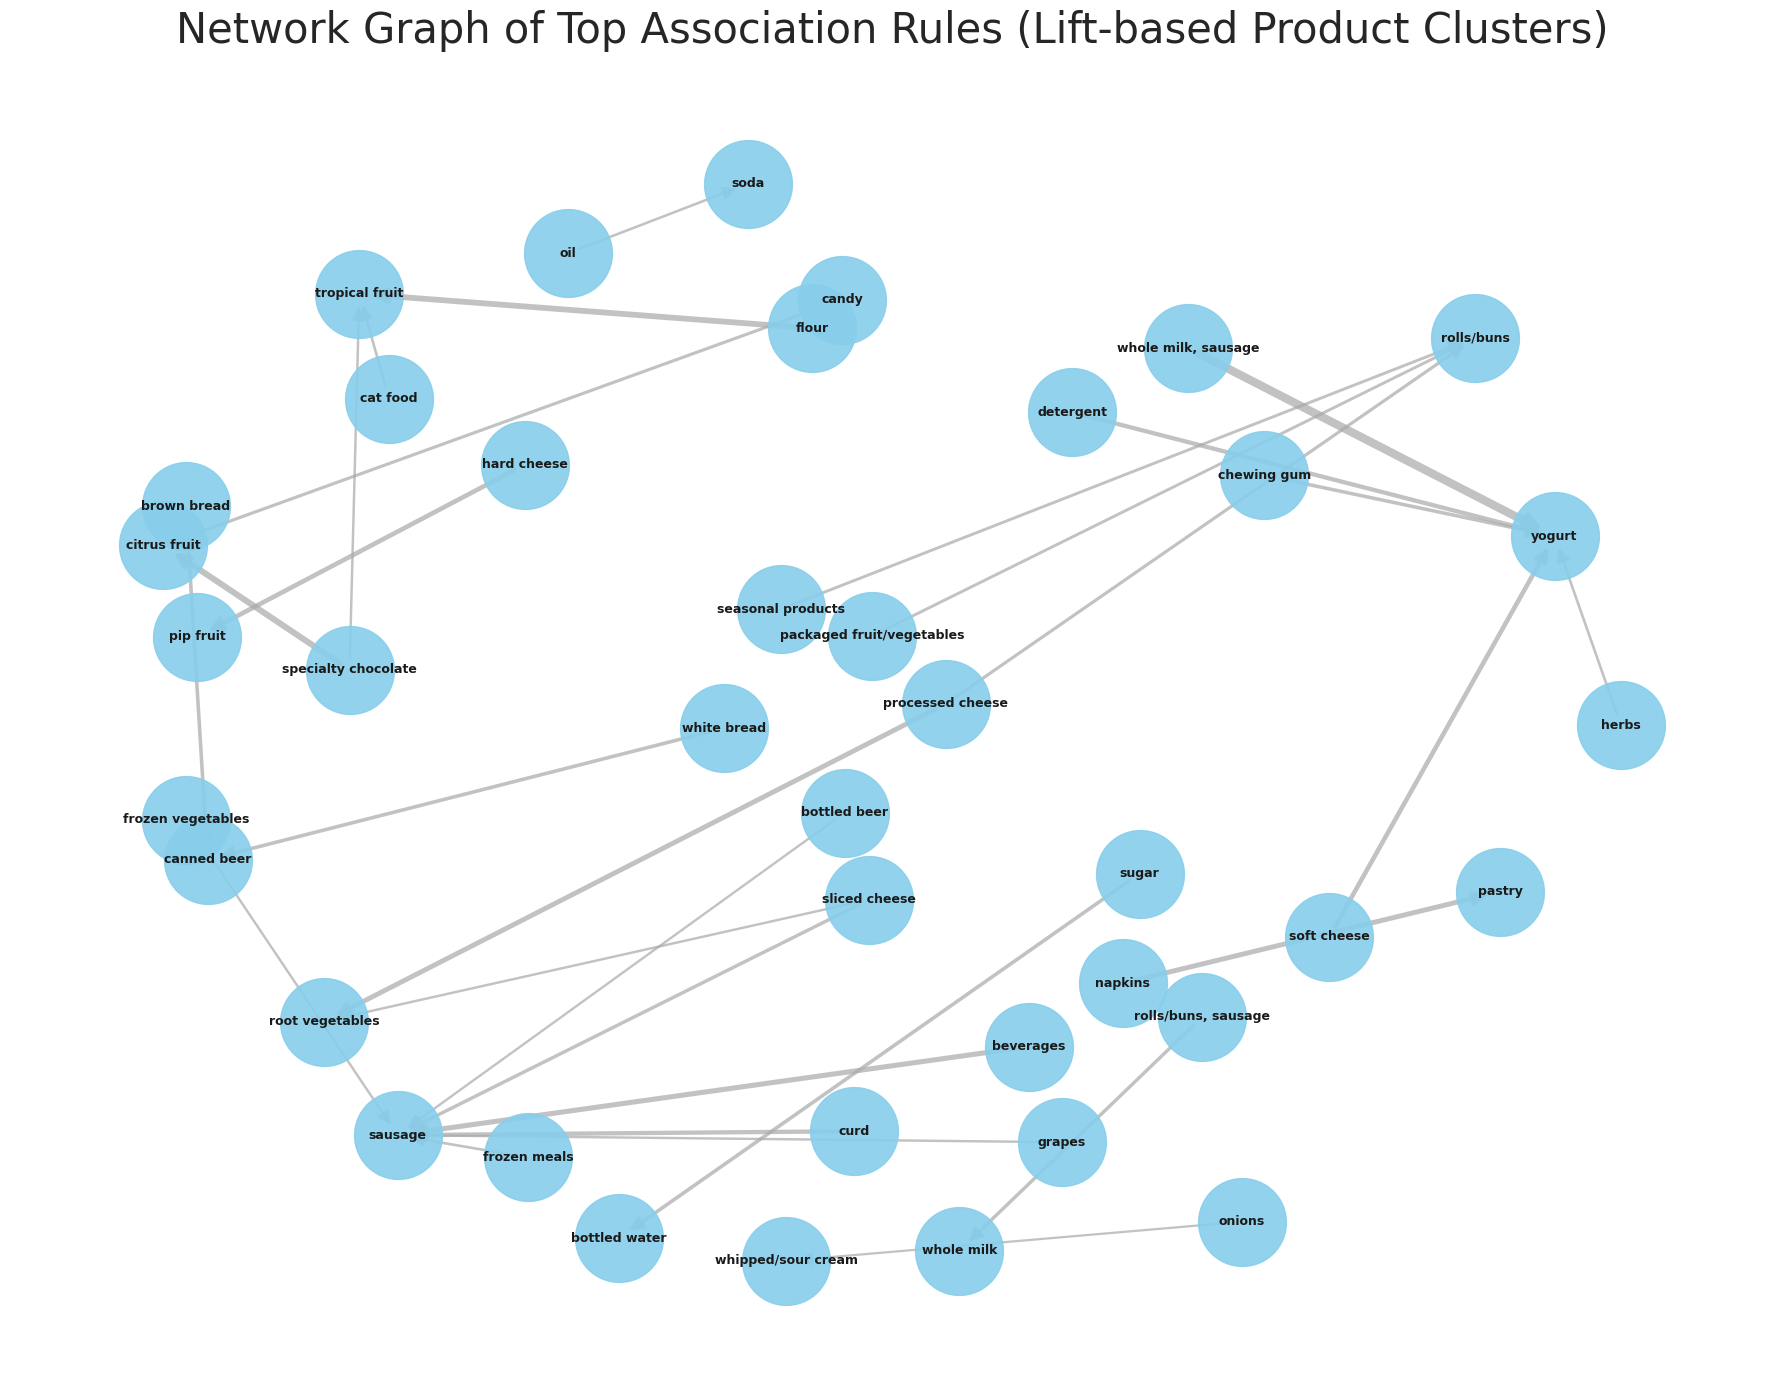

In [55]:
import networkx as nx
import matplotlib.pyplot as plt

# Filter for rules with high lift to visualize interesting relationships
# Taking the top 30 rules by 'Lifts'
strong_rules = resultsindataframe.nlargest(30, 'Lifts')

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges based on the strong_rules
for _, row in strong_rules.iterrows():
    lhs = row['Left Hand Side']
    rhs = row['Right Hand Side']
    lift = row['Lifts']
    confidence = row['Confidences']

    # Add edge from LHS to RHS, with lift and confidence as attributes
    G.add_edge(lhs, rhs, weight=lift, confidence=confidence)

# Get node positions using a layout algorithm for better visualization
pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42) # k adjusts distance between nodes

plt.figure(figsize=(18, 14))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=4000, alpha=0.9)

# Draw edges with varying thickness based on lift
edges = G.edges(data=True)
weights = [d['weight'] for u, v, d in edges]
# Normalize weights for edge thickness (e.g., between 1 and 6)
if weights:
    min_weight = min(weights)
    max_weight = max(weights)
    norm_weights = [(w - min_weight + 0.1) / (max_weight - min_weight + 0.1) * 5 + 1 for w in weights]
else:
    norm_weights = []

nx.draw_networkx_edges(G, pos, edgelist=edges, width=norm_weights, edge_color='darkgray', arrowsize=20, alpha=0.7)

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title('Network Graph of Top Association Rules (Lift-based Product Clusters)', size=30, pad=20)
plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()

This network graph, titled '**Network Graph of Top Association Rules (Lift-based Product Clusters)**', visualizes the relationships between different products based on the top 30 association rules with the highest 'Lifts'.

***Nodes (Circles):*** Each circle in the graph represents a specific product or item (e.g., 'whole milk', 'yogurt', 'sausage'). Products that appear as either the 'Left Hand Side' or 'Right Hand Side' of the strong association rules are shown as nodes.

***Edges (Lines/Arrows):*** The lines connecting the nodes represent an association rule. An arrow indicates the direction of the rule, from the 'Left Hand Side' (antecedent) to the 'Right Hand Side' (consequent). For example, an arrow from 'rolls/buns' to 'whole milk' signifies a rule {rolls/buns} -> {whole milk}.

***Edge Thickness:*** The thickness of each line (edge) is proportional to the 'Lift' value of the association rule it represents. Thicker lines indicate higher lift, meaning a stronger and more interesting association between the connected products. High lift values suggest that the co-occurrence of these products is significantly more frequent than what would be expected by chance, highlighting potential product clusters or purchase patterns.

***Clustering:*** The layout of the nodes is determined by an algorithm (spring layout in this case) that tries to place more strongly connected nodes closer together. This helps to visually identify 'clusters' of products that are frequently bought together or show strong associations, suggesting natural product groupings in customer purchasing behavior.

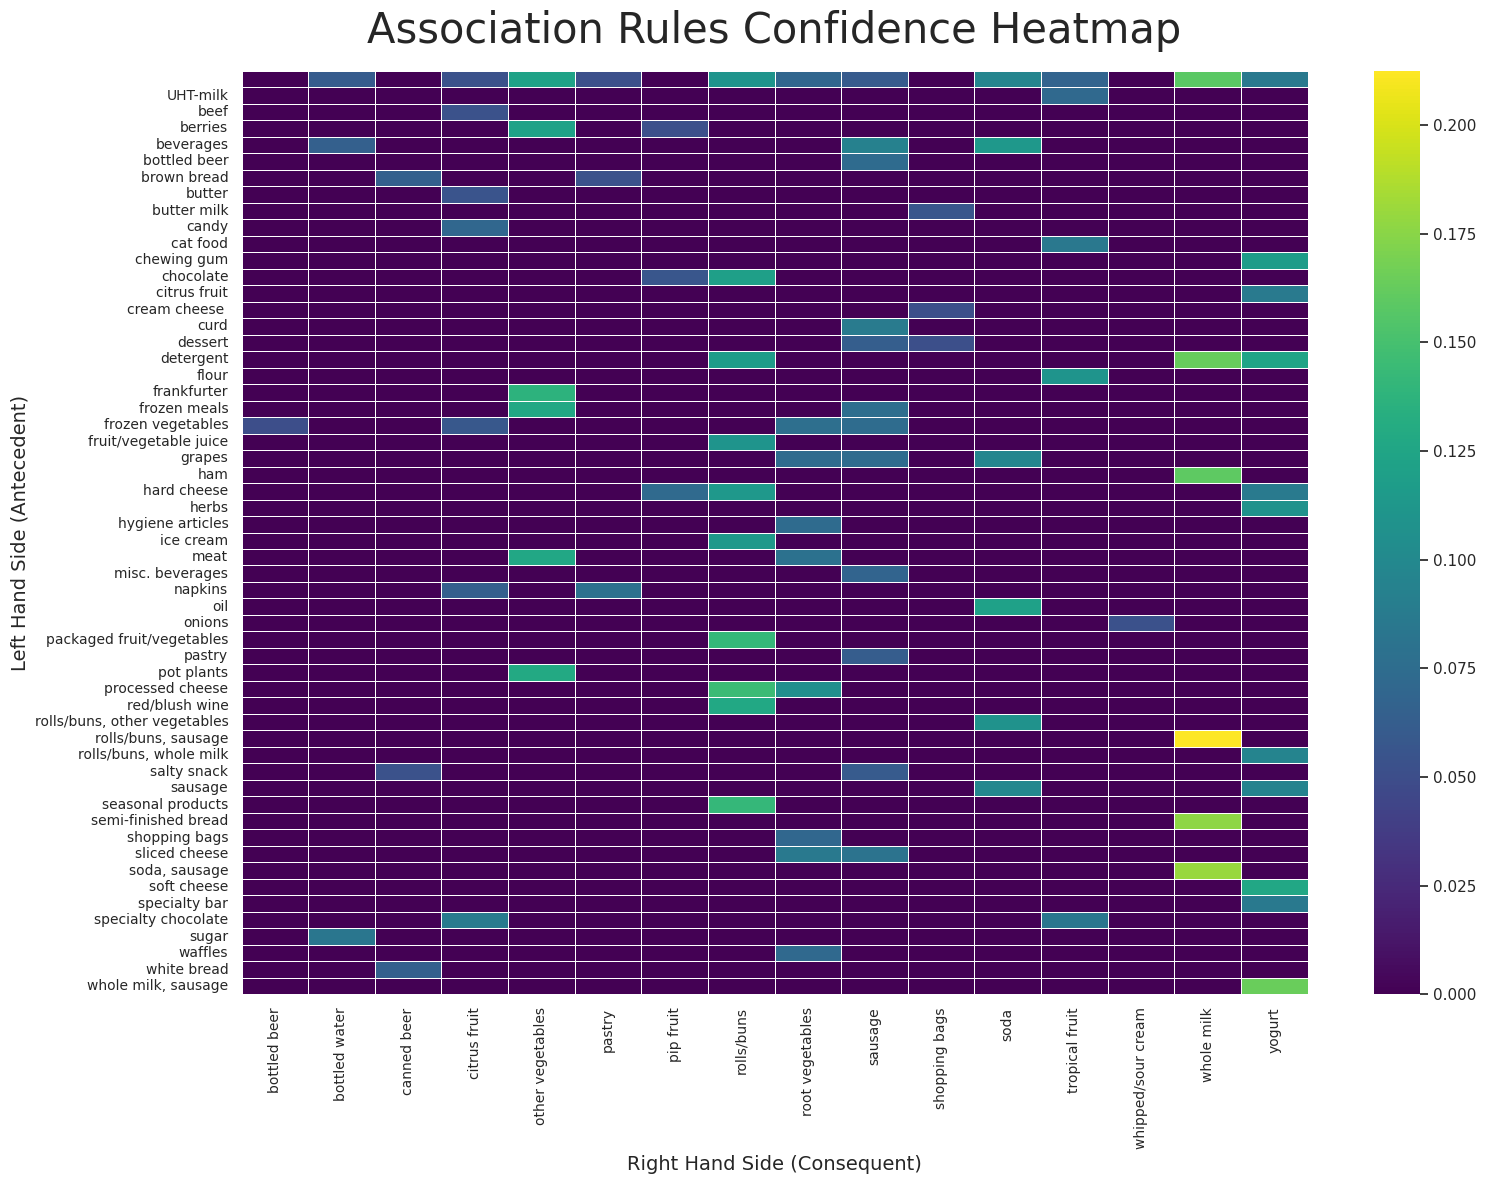

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for the heatmap
heatmap_data = resultsindataframe.pivot_table(
    index='Left Hand Side',
    columns='Right Hand Side',
    values='Confidences'
).fillna(0)

plt.figure(figsize=(16, 12))
sns.heatmap(heatmap_data, annot=False, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Association Rules Confidence Heatmap', fontsize=30, pad=20)
plt.xlabel('Right Hand Side (Consequent)', fontsize=14)
plt.ylabel('Left Hand Side (Antecedent)', fontsize=14)
plt.xticks(rotation=90, ha='center', fontsize=10) # Rotate x-axis labels for readability
plt.yticks(rotation=0, va='center', fontsize=10)   # Keep y-axis labels horizontal
plt.tight_layout()
plt.show()

This heatmap, titled '**Association Rules Confidence Heatmap**', provides a visual representation of the 'Confidences' for various association rules. It helps to quickly identify strong relationships between different items.

***The y-axis (Left Hand Side (Antecedent))*** lists items or itemsets that serve as the antecedent of an association rule (i.e., 'if they buy this...').

***The x-axis (Right Hand Side (Consequent))*** lists items or itemsets that serve as the consequent of an association rule (i.e., '...then they also buy this').

***Each cell in the heatmap*** represents a potential association rule where the y-axis item(s) lead to the x-axis item(s). The **color intensity** of each cell corresponds to the 'Confidence' of that specific rule. A brighter or more vibrant color (towards yellow in the 'viridis' colormap) indicates a higher confidence, meaning that the consequent item(s) are more likely to be purchased when the antecedent item(s) are present. Black or very dark cells indicate a confidence of zero, meaning no such rule exists or its confidence is extremely low. This allows for a quick visual scan to pinpoint which antecedent-consequent pairs have the strongest confidence.

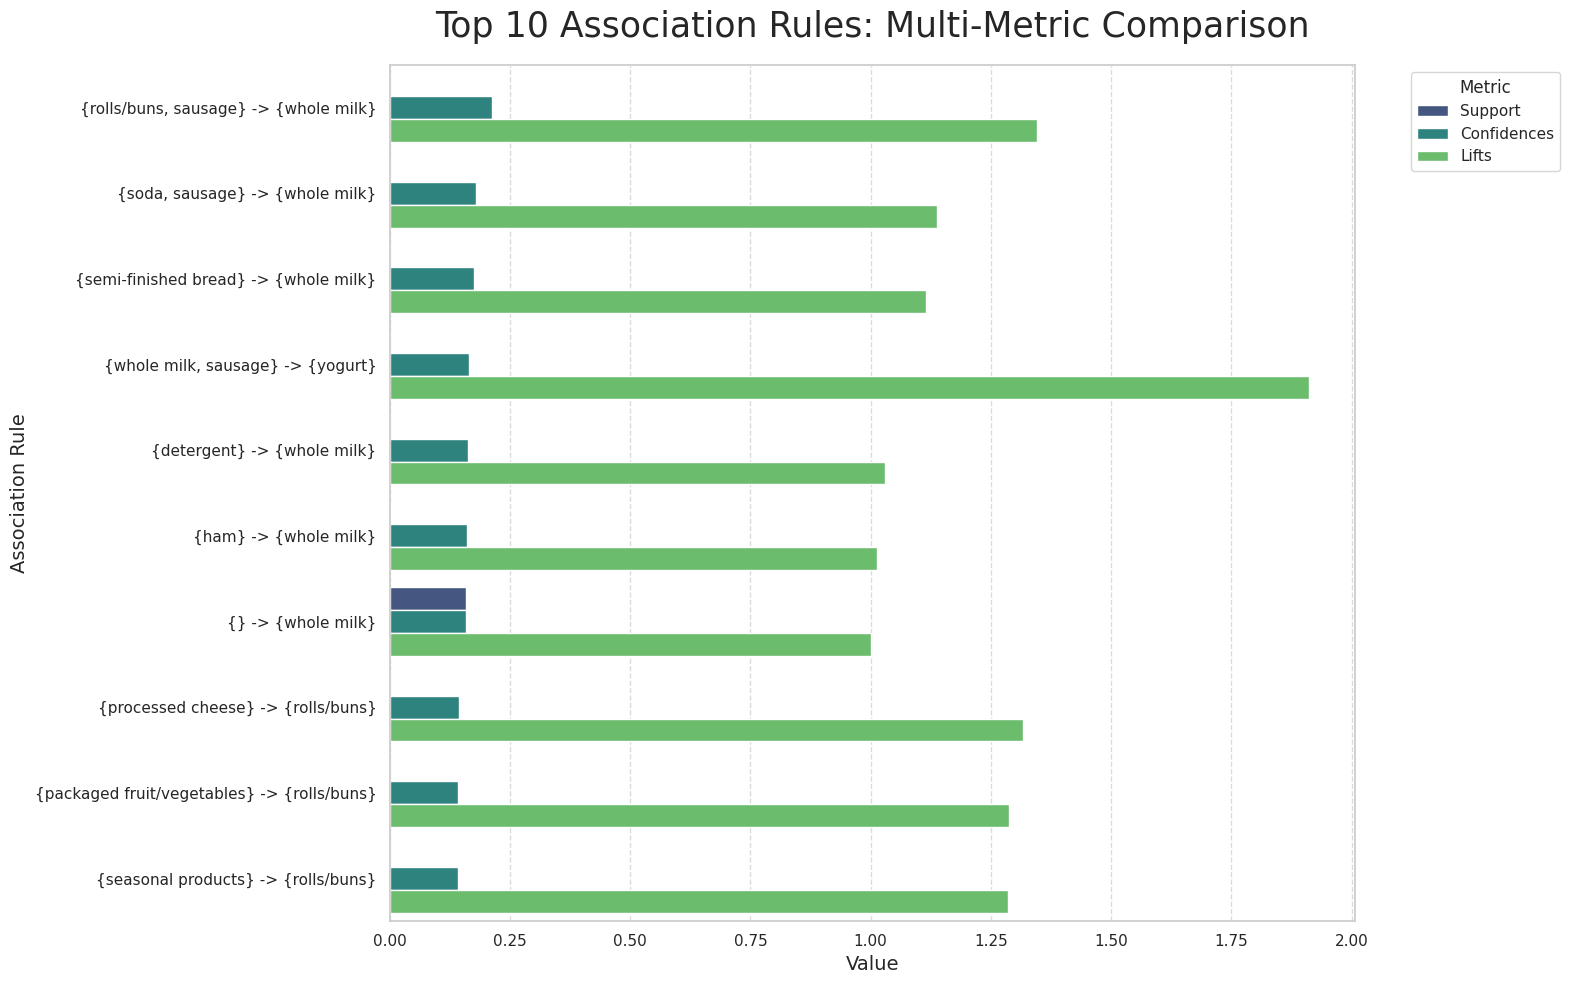

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select the top 10 rules for multi-metric comparison
# Using the previously defined 'top_15_confidence' and taking the first 10 for better readability
rules_for_comparison = top_15_confidence.head(10).copy()

# Combine 'Left Hand Side' and 'Right Hand Side' for better labels on the chart
rules_for_comparison['Rule'] = rules_for_comparison.apply(lambda x: f"{{{x['Left Hand Side']}}} -> {{{x['Right Hand Side']}}}", axis=1)

# Melt the DataFrame to long format for Seaborn bar plot
melted_rules = rules_for_comparison.melt(id_vars=['Rule'], value_vars=['Support', 'Confidences', 'Lifts'],
                                       var_name='Metric', value_name='Value')

plt.figure(figsize=(16, 10))
sns.barplot(x='Value', y='Rule', hue='Metric', data=melted_rules, palette='viridis')

plt.title('Top 10 Association Rules: Multi-Metric Comparison', fontsize=25, pad=20)
plt.xlabel('Value', fontsize=14)
plt.ylabel('Association Rule', fontsize=14)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart, titled '**Top 10 Association Rules: Multi-Metric Comparison**', provides a side-by-side comparison of three key metrics – Support, Confidences, and Lifts – for the top 10 association rules.

***The y-axis (Association Rule)*** lists the top 10 association rules, each formatted as 'Left Hand Side -> Right Hand Side'.

***The x-axis (Value)*** represents the numerical value of each metric.
For each association rule, there are three bars grouped together, each representing a different metric:

***Support (dark blue/purple bar):*** Indicates how frequently the itemset of that rule appears in the dataset.

***Confidences (teal/green bar):*** Measures the reliability of the rule, showing the probability that the consequent is purchased given the antecedent.

***Lifts (lighter green bar):*** Shows how much more likely the items in the rule are purchased together than by chance. A lift greater than 1 suggests a positive association.

This visualization allows for a direct comparison of all three metrics for each rule, making it easy to identify rules that are high in confidence, lift, and support simultaneously, or to understand trade-offs between these metrics.